# Fair Price via Feasible Dynamic Hedging

This notebook estimates a bilateral fair price for a generally path-dependent contract using feasible discrete-time dynamic hedging. The portfolio contains only the underlying asset and the bank account.

The stock position is a bounded finite sigmoidal expansion

$$a_k = a_{\max}\tanh\left(c_0+\sum_{j=1}^{m} c_j\sigma(w_j^\top X_k+b_j)\right),$$

where the user chooses `m = N_SIGMOIDAL_FUNCTIONS`. The default is `m = 2` for fast runs.


In [1]:
# Install Yahoo Finance downloader in Colab.
!pip -q install yfinance


In [2]:
# Fair Price via Feasible Dynamic Hedging
# Portfolio instruments: underlying asset + bank account only.
# Daily rebalancing. Path-dependent payoff allowed.
# The stock position is a bounded finite sigmoidal expansion with user-selected size m.



## Imports


In [3]:
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
from torch import nn
import torch.nn.functional as F

# Reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)



Using device: cpu


## User inputs


In [4]:
# Set USE_INTERACTIVE_INPUTS = False if you prefer to hard-code the inputs.
USE_INTERACTIVE_INPUTS = True
DEFAULT_N_SIGMOIDAL_FUNCTIONS = 2

if USE_INTERACTIVE_INPUTS:
    TICKER = input("Ticker, e.g. AAPL, MSFT, SPY: ").strip().upper() or "AAPL"
    T_DAYS = int(input("Maturity T in trading days, e.g. 63: ").strip() or "63")
    N_SIGMOIDAL_FUNCTIONS = int(
        input("Number of sigmoidal functions m, e.g. 2 for fast runs: ").strip()
        or str(DEFAULT_N_SIGMOIDAL_FUNCTIONS)
    )
else:
    TICKER = "AAPL"
    T_DAYS = 63
    N_SIGMOIDAL_FUNCTIONS = DEFAULT_N_SIGMOIDAL_FUNCTIONS

# Keep at least one basis function.
N_SIGMOIDAL_FUNCTIONS = max(1, int(N_SIGMOIDAL_FUNCTIONS))

# Historical lookback used to generate scenarios.
HISTORY_YEARS = 10

# Number of historical-return scenarios. Increase this for more stable results.
N_SCENARIOS = 1500

# Train/validation split. Validation CVaR is used for the reported fair-price comparison.
TRAIN_FRACTION = 0.80

# Annual continuously compounded risk-free rate.
R_ANNUAL = 0.03

# CVaR confidence level.
ALPHA = 0.95

# Contract settings. The payoff is for one contract unit, not a 100-share option lot.
# Supported: "european_call", "european_put", "asian_call", "asian_put",
#            "lookback_call", "lookback_put", "up_and_out_call", "down_and_out_put".
CONTRACT_TYPE = "lookback_call"
CONTRACT_MULTIPLIER = 1.0

# If STRIKE is None, it will be set to the latest downloaded spot price S0.
STRIKE = None

# If BARRIER is None, it will be set automatically for barrier examples.
BARRIER = None

# Position bound in shares per contract unit.
# For one vanilla call, values around 1-2 are natural. Increase for more aggressive hedging.
A_MAX_MULTIPLIER = 2.0

# Optimization settings.
# The stock position is represented by m finite sigmoidal basis functions.
# Start with m=2 for speed; increase to 4, 8, 16, ... for richer hedges.
SIGMOIDAL_ACTIVATION = "tanh"  # Supported: "tanh" or "logistic".
EPOCHS = 350
LEARNING_RATE = 2e-3
POSITION_PENALTY = 1e-5
N_RESTARTS = 1

# Fair-price grid settings. Increase N_PRICE_GRID for smoother but slower pricing.
N_PRICE_GRID = 9

print({
    "ticker": TICKER,
    "T_days": T_DAYS,
    "contract": CONTRACT_TYPE,
    "history_years": HISTORY_YEARS,
    "n_scenarios": N_SCENARIOS,
    "alpha": ALPHA,
    "n_sigmoidal_functions": N_SIGMOIDAL_FUNCTIONS,
})



Ticker, e.g. AAPL, MSFT, SPY: AAPL
Maturity T in trading days, e.g. 63: 60
Number of sigmoidal functions m, e.g. 2 for fast runs: 4
{'ticker': 'AAPL', 'T_days': 60, 'contract': 'lookback_call', 'history_years': 10, 'n_scenarios': 1500, 'alpha': 0.95, 'n_sigmoidal_functions': 4}


## Data download and scenario generation


Latest adjusted close S0 for AAPL: 300.2300
Strike K: 300.2300
Scenario paths shape: (1500, 61)
Position bound a_max: 2.0000 shares per contract unit


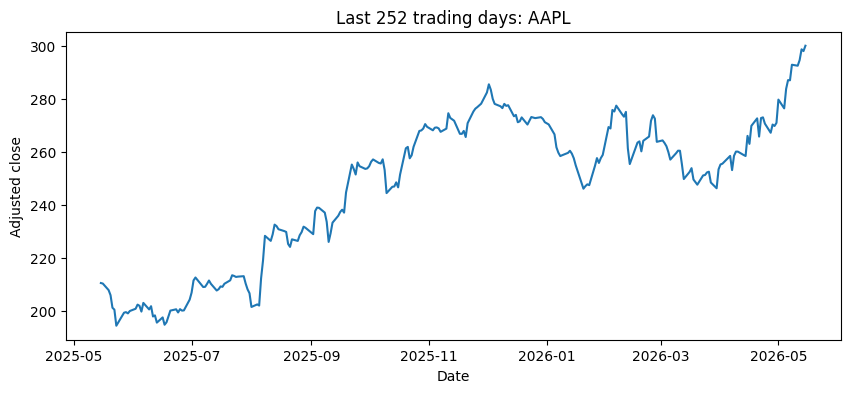

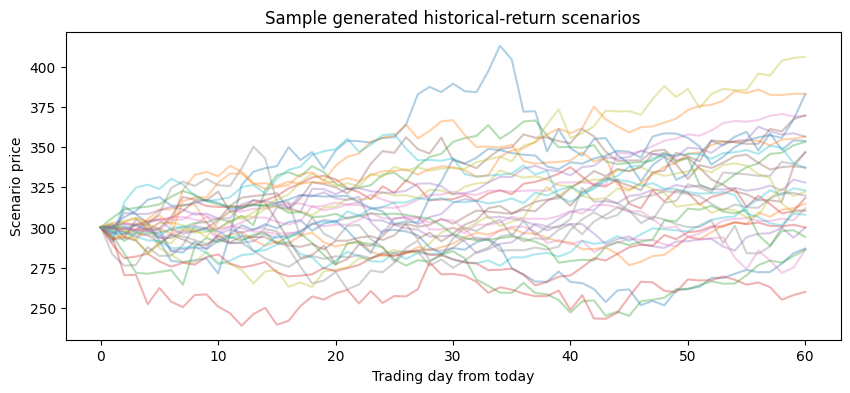

In [5]:
def extract_close_column(raw: pd.DataFrame) -> pd.Series:
    """Extract a single Close column from yfinance output, robustly handling MultiIndex columns."""
    if raw.empty:
        raise ValueError("Downloaded data is empty. Check the ticker or Yahoo Finance availability.")

    if isinstance(raw.columns, pd.MultiIndex):
        # yfinance may return MultiIndex columns even for one ticker.
        for level in range(raw.columns.nlevels):
            labels = list(raw.columns.get_level_values(level))
            if "Close" in labels:
                close = raw.xs("Close", axis=1, level=level)
                if isinstance(close, pd.DataFrame):
                    close = close.iloc[:, 0]
                return close.dropna().astype(float)
        raise ValueError("Could not find a Close column in the downloaded MultiIndex data.")

    if "Close" not in raw.columns:
        raise ValueError("Could not find a Close column in the downloaded data.")
    return raw["Close"].dropna().astype(float)


def download_adjusted_close(ticker: str, history_years: int = 10) -> pd.Series:
    """Download adjusted daily close prices from Yahoo Finance through yfinance."""
    period = f"{history_years}y"
    raw = yf.download(
        tickers=ticker,
        period=period,
        interval="1d",
        auto_adjust=True,
        progress=False,
        threads=True,
    )
    close = extract_close_column(raw)
    if len(close) < 260:
        warnings.warn("The downloaded history is short; scenario generation may be unstable.")
    return close


def make_historical_scenarios(
    close: pd.Series,
    horizon_days: int,
    n_scenarios: int,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create future price paths by sampling historical daily log-return blocks.

    Returns
    -------
    paths : array, shape (n_scenarios, horizon_days + 1)
        Price paths starting at the latest observed spot S0.
    sampled_returns : array, shape (n_scenarios, horizon_days)
        The sampled log-return blocks used to build the paths.
    """
    if horizon_days < 1:
        raise ValueError("horizon_days must be positive.")

    rng = np.random.default_rng(seed)
    s0 = float(close.iloc[-1])
    log_returns = np.log(close / close.shift(1)).dropna().to_numpy(dtype=float)

    if len(log_returns) >= horizon_days:
        # Rolling blocks preserve local serial dependence inside each block.
        windows = np.lib.stride_tricks.sliding_window_view(log_returns, window_shape=horizon_days)
        replace = len(windows) < n_scenarios
        idx = rng.choice(len(windows), size=n_scenarios, replace=replace)
        sampled_returns = windows[idx]
    else:
        # Fallback for very long maturities relative to history.
        warnings.warn(
            "T_DAYS exceeds available return history; using iid bootstrap of daily returns instead of rolling blocks."
        )
        sampled_returns = rng.choice(log_returns, size=(n_scenarios, horizon_days), replace=True)

    future_prices = s0 * np.exp(np.cumsum(sampled_returns, axis=1))
    paths = np.concatenate([np.full((n_scenarios, 1), s0), future_prices], axis=1)
    return paths.astype(np.float32), sampled_returns.astype(np.float32)


close = download_adjusted_close(TICKER, HISTORY_YEARS)
S0 = float(close.iloc[-1])

if STRIKE is None:
    STRIKE = S0
if BARRIER is None:
    # Default barriers are only used by barrier payoff examples.
    if CONTRACT_TYPE == "up_and_out_call":
        BARRIER = 1.25 * S0
    elif CONTRACT_TYPE == "down_and_out_put":
        BARRIER = 0.75 * S0
    else:
        BARRIER = np.nan

A_MAX = A_MAX_MULTIPLIER * CONTRACT_MULTIPLIER

paths, sampled_returns = make_historical_scenarios(
    close=close,
    horizon_days=T_DAYS,
    n_scenarios=N_SCENARIOS,
    seed=SEED,
)

print(f"Latest adjusted close S0 for {TICKER}: {S0:.4f}")
print(f"Strike K: {STRIKE:.4f}")
print(f"Scenario paths shape: {paths.shape}")
print(f"Position bound a_max: {A_MAX:.4f} shares per contract unit")

plt.figure(figsize=(10, 4))
plt.plot(close.tail(252))
plt.title(f"Last 252 trading days: {TICKER}")
plt.xlabel("Date")
plt.ylabel("Adjusted close")
plt.show()

plt.figure(figsize=(10, 4))
for i in range(min(30, len(paths))):
    plt.plot(paths[i], alpha=0.35)
plt.title("Sample generated historical-return scenarios")
plt.xlabel("Trading day from today")
plt.ylabel("Scenario price")
plt.show()



## Path-dependent payoff


ContractConfig(contract_type='lookback_call', strike=300.2300109863281, barrier=None, multiplier=1.0)
count    1500.000000
mean       41.839317
std        31.348127
min         0.000000
50%        36.402206
90%        79.658359
95%        97.819511
99%       148.126562
max       183.875854
dtype: float64


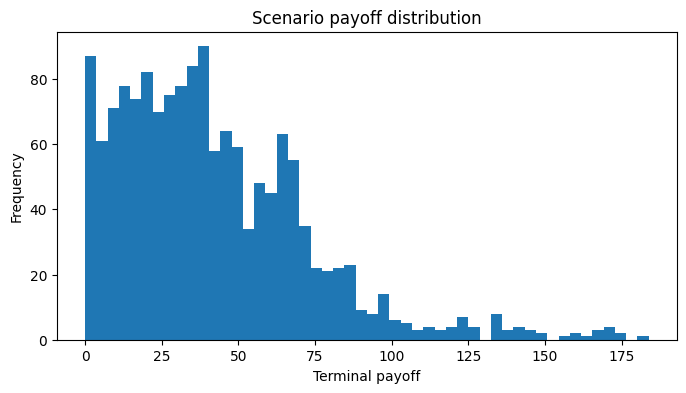

In [6]:
@dataclass
class ContractConfig:
    contract_type: str
    strike: float
    barrier: Optional[float] = None
    multiplier: float = 1.0


def compute_contract_payoff(paths: np.ndarray, contract: ContractConfig) -> np.ndarray:
    """
    Compute the path-dependent terminal payoff for each scenario.

    To implement a custom path-dependent claim, add a new branch below.
    The returned payoff is in terminal currency units, before discounting.
    """
    ctype = contract.contract_type.lower()
    K = float(contract.strike)
    multiplier = float(contract.multiplier)

    S_full = paths
    S_future = paths[:, 1:]
    S_T = paths[:, -1]

    if ctype == "european_call":
        payoff = np.maximum(S_T - K, 0.0)

    elif ctype == "european_put":
        payoff = np.maximum(K - S_T, 0.0)

    elif ctype == "asian_call":
        avg_price = S_future.mean(axis=1)
        payoff = np.maximum(avg_price - K, 0.0)

    elif ctype == "asian_put":
        avg_price = S_future.mean(axis=1)
        payoff = np.maximum(K - avg_price, 0.0)

    elif ctype == "lookback_call":
        running_max = S_full.max(axis=1)
        payoff = np.maximum(running_max - K, 0.0)

    elif ctype == "lookback_put":
        running_min = S_full.min(axis=1)
        payoff = np.maximum(K - running_min, 0.0)

    elif ctype == "up_and_out_call":
        if contract.barrier is None or not np.isfinite(contract.barrier):
            raise ValueError("up_and_out_call requires a finite upper barrier.")
        knocked_out = S_full.max(axis=1) >= float(contract.barrier)
        payoff = np.where(knocked_out, 0.0, np.maximum(S_T - K, 0.0))

    elif ctype == "down_and_out_put":
        if contract.barrier is None or not np.isfinite(contract.barrier):
            raise ValueError("down_and_out_put requires a finite lower barrier.")
        knocked_out = S_full.min(axis=1) <= float(contract.barrier)
        payoff = np.where(knocked_out, 0.0, np.maximum(K - S_T, 0.0))

    else:
        raise ValueError(f"Unsupported contract_type: {contract.contract_type}")

    return (multiplier * payoff).astype(np.float32)


contract = ContractConfig(
    contract_type=CONTRACT_TYPE,
    strike=float(STRIKE),
    barrier=None if not np.isfinite(BARRIER) else float(BARRIER),
    multiplier=float(CONTRACT_MULTIPLIER),
)

payoff = compute_contract_payoff(paths, contract)

print(contract)
print(pd.Series(payoff).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(payoff, bins=50)
plt.title("Scenario payoff distribution")
plt.xlabel("Terminal payoff")
plt.ylabel("Frequency")
plt.show()



## Discounted market and self-financing portfolio


In [7]:
def discount_market(
    paths: np.ndarray,
    payoff: np.ndarray,
    r_annual: float,
    trading_days_per_year: int = 252,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Convert stock paths and payoff to discounted units."""
    n_steps = paths.shape[1] - 1
    t = np.arange(n_steps + 1, dtype=np.float32) / float(trading_days_per_year)
    bank = np.exp(float(r_annual) * t).astype(np.float32)
    discounted_paths = paths / bank[None, :]
    discounted_payoff = payoff / bank[-1]
    return discounted_paths.astype(np.float32), discounted_payoff.astype(np.float32), bank


S_disc, payoff_disc, bank_account = discount_market(paths, payoff, R_ANNUAL)
print("Terminal bank-account growth B_T:", float(bank_account[-1]))
print("Mean discounted payoff:", float(payoff_disc.mean()))



Terminal bank-account growth B_T: 1.0071684122085571
Mean discounted payoff: 41.54153060913086


## State features for the finite sigmoidal feedback hedge


In [8]:
def build_state_features(paths: np.ndarray, strike: float) -> np.ndarray:
    """
    Build non-anticipative state features for each scenario and rebalancing date.

    Output shape is (n_scenarios, n_steps, n_features).
    Features at time k use only path values up to and including S_k.
    """
    paths = np.asarray(paths, dtype=np.float32)
    M, N_plus_1 = paths.shape
    N = N_plus_1 - 1
    S0 = paths[:, [0]]
    spot = paths[:, :-1]

    running_max = np.maximum.accumulate(paths, axis=1)[:, :-1]
    running_min = np.minimum.accumulate(paths, axis=1)[:, :-1]
    running_sum = np.cumsum(paths, axis=1)[:, :-1]
    counts = np.arange(1, N + 1, dtype=np.float32)[None, :]
    running_avg = running_sum / counts

    full_log = np.log(paths)
    observed_log_returns = np.diff(full_log, axis=1)

    last_return = np.zeros((M, N), dtype=np.float32)
    if N > 1:
        # At time k, the latest observed return is S_k/S_{k-1}; do not use S_{k+1}.
        last_return[:, 1:] = observed_log_returns[:, :-1]

    realized_vol = np.zeros((M, N), dtype=np.float32)
    lookback = 21
    for k in range(1, N):
        start = max(0, k - lookback)
        window = observed_log_returns[:, start:k]
        realized_vol[:, k] = window.std(axis=1) * math.sqrt(252.0)

    time_left = ((N - np.arange(N, dtype=np.float32)) / float(N))[None, :]
    time_left = np.repeat(time_left, repeats=M, axis=0)

    log_spot_rel = np.log(spot / S0)
    log_moneyness = np.log(spot / float(strike))
    run_max_rel = running_max / S0 - 1.0
    run_min_rel = running_min / S0 - 1.0
    run_avg_rel = running_avg / S0 - 1.0
    drawdown = spot / np.maximum(running_max, 1e-12) - 1.0

    features = np.stack(
        [
            log_spot_rel,
            log_moneyness,
            run_max_rel,
            run_min_rel,
            run_avg_rel,
            drawdown,
            last_return,
            realized_vol,
            time_left,
        ],
        axis=-1,
    )
    return features.astype(np.float32)


class StandardScaler3D:
    """Simple scaler for arrays shaped (n_scenarios, n_steps, n_features)."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X: np.ndarray):
        flat = X.reshape(-1, X.shape[-1])
        self.mean_ = flat.mean(axis=0, keepdims=True).astype(np.float32)
        self.std_ = flat.std(axis=0, keepdims=True).astype(np.float32)
        self.std_ = np.where(self.std_ < 1e-8, 1.0, self.std_)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError("Scaler has not been fitted.")
        return ((X - self.mean_[None, :, :]) / self.std_[None, :, :]).astype(np.float32)


def split_train_validation(n: int, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """Create train and validation indices."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_train = int(round(train_fraction * n))
    n_train = min(max(n_train, 1), n - 1)
    return idx[:n_train], idx[n_train:]


features_raw = build_state_features(paths, STRIKE)
train_idx, val_idx = split_train_validation(len(paths), TRAIN_FRACTION, SEED)

scaler = StandardScaler3D().fit(features_raw[train_idx])
features = scaler.transform(features_raw)

train_data = {
    "features": features[train_idx],
    "S_disc": S_disc[train_idx],
    "payoff_disc": payoff_disc[train_idx],
}
val_data = {
    "features": features[val_idx],
    "S_disc": S_disc[val_idx],
    "payoff_disc": payoff_disc[val_idx],
}

print("Raw feature shape:", features_raw.shape)
print("Train scenarios:", len(train_idx), "Validation scenarios:", len(val_idx))



Raw feature shape: (1500, 60, 9)
Train scenarios: 1200 Validation scenarios: 300


## Dynamic hedging model and CVaR optimization


In [9]:
@dataclass
class OptimConfig:
    alpha: float = 0.95
    epochs: int = 350
    lr: float = 2e-3
    n_sigmoidal_functions: int = 2
    sigmoid_activation: str = "tanh"
    position_penalty: float = 1e-5
    n_restarts: int = 1
    seed: int = 42


class SigmoidalDeltaNet(nn.Module):
    """
    Bounded finite sigmoidal expansion for the stock position.

    a_k = a_max * tanh(c0 + sum_j c_j * sigma(w_j^T X_k + b_j))

    The same parameters are shared across dates, while time-to-maturity is included
    in X_k. This keeps the model small and fast while preserving time dependence.
    """

    def __init__(
        self,
        input_dim: int,
        a_max: float,
        n_sigmoidal_functions: int = 2,
        sigmoid_activation: str = "tanh",
    ):
        super().__init__()
        if n_sigmoidal_functions < 1:
            raise ValueError("n_sigmoidal_functions must be at least 1.")
        if sigmoid_activation not in {"tanh", "logistic"}:
            raise ValueError("sigmoid_activation must be 'tanh' or 'logistic'.")

        self.input_to_basis = nn.Linear(input_dim, n_sigmoidal_functions)
        self.basis_to_output = nn.Linear(n_sigmoidal_functions, 1, bias=True)
        self.a_max = float(a_max)
        self.sigmoid_activation = sigmoid_activation

    def _basis_activation(self, z: torch.Tensor) -> torch.Tensor:
        # Both tanh and logistic are sigmoidal functions.
        if self.sigmoid_activation == "logistic":
            return torch.sigmoid(z)
        return torch.tanh(z)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # X has shape (batch, n_steps, input_dim).
        basis_values = self._basis_activation(self.input_to_basis(X))
        raw = self.basis_to_output(basis_values).squeeze(-1)
        return self.a_max * torch.tanh(raw)


def terminal_pnl(
    model: nn.Module,
    X: torch.Tensor,
    S_disc_t: torch.Tensor,
    payoff_disc_t: torch.Tensor,
    x: float,
    epsilon: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Compute discounted terminal P&L for a self-financing stock+bank strategy.

    pnl = x + sum_k a_k * (S_{k+1} - S_k) + epsilon * payoff
    epsilon = -1 for writer, +1 for buyer.
    """
    a = model(X)
    dS = S_disc_t[:, 1:] - S_disc_t[:, :-1]
    trading_gains = torch.sum(a * dS, dim=1)
    pnl = float(x) + trading_gains + int(epsilon) * payoff_disc_t
    return pnl, a


def cvar_rockafellar_uryasev(losses: torch.Tensor, eta: torch.Tensor, alpha: float) -> torch.Tensor:
    """Differentiable empirical CVaR objective for a trainable eta."""
    return eta + torch.mean(F.relu(losses - eta)) / (1.0 - float(alpha))


def empirical_cvar_np(losses: np.ndarray, alpha: float) -> float:
    """Empirical CVaR using the Rockafellar-Uryasev representation at the empirical quantile."""
    losses = np.asarray(losses, dtype=float)
    q = float(np.quantile(losses, alpha))
    return float(q + np.mean(np.maximum(losses - q, 0.0)) / (1.0 - alpha))


def to_torch_data(data: Dict[str, np.ndarray]) -> Dict[str, torch.Tensor]:
    """Move scenario arrays to the selected PyTorch device."""
    return {
        "features": torch.as_tensor(data["features"], dtype=torch.float32, device=DEVICE),
        "S_disc": torch.as_tensor(data["S_disc"], dtype=torch.float32, device=DEVICE),
        "payoff_disc": torch.as_tensor(data["payoff_disc"], dtype=torch.float32, device=DEVICE),
    }


def evaluate_strategy(
    model: nn.Module,
    data: Dict[str, np.ndarray],
    x: float,
    epsilon: int,
    alpha: float,
) -> Dict[str, float]:
    """Evaluate mean P&L, downside loss, VaR, CVaR, and average absolute position."""
    model.eval()
    tdata = to_torch_data(data)
    with torch.no_grad():
        pnl, a = terminal_pnl(model, tdata["features"], tdata["S_disc"], tdata["payoff_disc"], x, epsilon)
    pnl_np = pnl.detach().cpu().numpy()
    a_np = a.detach().cpu().numpy()
    losses = np.maximum(-pnl_np, 0.0)
    return {
        "mean_pnl": float(np.mean(pnl_np)),
        "std_pnl": float(np.std(pnl_np)),
        "mean_loss": float(np.mean(losses)),
        "var_loss": float(np.quantile(losses, alpha)),
        "cvar_loss": empirical_cvar_np(losses, alpha),
        "prob_loss": float(np.mean(pnl_np < 0.0)),
        "avg_abs_position": float(np.mean(np.abs(a_np))),
    }


def train_one_strategy(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
    x: float,
    epsilon: int,
    a_max: float,
    config: OptimConfig,
    restart_seed: int,
) -> Dict[str, Any]:
    """Train one dynamic hedging strategy for a fixed premium side."""
    torch.manual_seed(restart_seed)
    np.random.seed(restart_seed)
    random.seed(restart_seed)

    input_dim = train_data["features"].shape[-1]
    model = SigmoidalDeltaNet(
        input_dim=input_dim,
        a_max=a_max,
        n_sigmoidal_functions=config.n_sigmoidal_functions,
        sigmoid_activation=config.sigmoid_activation,
    ).to(DEVICE)

    # Initial eta is set from the no-hedge downside loss, which stabilizes CVaR training.
    nohedge_pnl = float(x) + int(epsilon) * train_data["payoff_disc"]
    nohedge_losses = np.maximum(-nohedge_pnl, 0.0)
    eta0 = float(np.quantile(nohedge_losses, config.alpha))
    eta = nn.Parameter(torch.tensor(eta0, dtype=torch.float32, device=DEVICE))

    optimizer = torch.optim.Adam(list(model.parameters()) + [eta], lr=config.lr)
    ttrain = to_torch_data(train_data)

    history = []
    for epoch in range(config.epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        pnl, a = terminal_pnl(
            model=model,
            X=ttrain["features"],
            S_disc_t=ttrain["S_disc"],
            payoff_disc_t=ttrain["payoff_disc"],
            x=x,
            epsilon=epsilon,
        )
        losses = F.relu(-pnl)
        cvar_obj = cvar_rockafellar_uryasev(losses, eta, config.alpha)

        # A small regularizer discourages unnecessarily violent stock positions.
        objective = cvar_obj + config.position_penalty * torch.mean(a * a)
        objective.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [eta], max_norm=10.0)
        optimizer.step()

        if epoch % max(1, config.epochs // 10) == 0 or epoch == config.epochs - 1:
            history.append(float(cvar_obj.detach().cpu()))

    train_stats = evaluate_strategy(model, train_data, x, epsilon, config.alpha)
    val_stats = evaluate_strategy(model, val_data, x, epsilon, config.alpha)

    return {
        "model": model,
        "eta": float(eta.detach().cpu()),
        "train": train_stats,
        "validation": val_stats,
        "history": history,
        "x": float(x),
        "epsilon": int(epsilon),
    }


def train_best_strategy(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
    x: float,
    epsilon: int,
    a_max: float,
    config: OptimConfig,
) -> Dict[str, Any]:
    """Train several restarts and keep the model with lowest validation CVaR."""
    best = None
    for r in range(config.n_restarts):
        bundle = train_one_strategy(
            train_data=train_data,
            val_data=val_data,
            x=x,
            epsilon=epsilon,
            a_max=a_max,
            config=config,
            restart_seed=config.seed + 1000 * r + 17 * int(epsilon + 2),
        )
        if best is None or bundle["validation"]["cvar_loss"] < best["validation"]["cvar_loss"]:
            best = bundle
    return best


optim_config = OptimConfig(
    alpha=ALPHA,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    n_sigmoidal_functions=N_SIGMOIDAL_FUNCTIONS,
    sigmoid_activation=SIGMOIDAL_ACTIVATION,
    position_penalty=POSITION_PENALTY,
    n_restarts=N_RESTARTS,
    seed=SEED,
)

print(optim_config)



OptimConfig(alpha=0.95, epochs=350, lr=0.002, n_sigmoidal_functions=4, sigmoid_activation='tanh', position_penalty=1e-05, n_restarts=1, seed=42)


## Fair-price search


Candidate premium grid:
[  0.          22.98004494  45.96008987  68.94013481  91.92017975
 114.90022469 137.88026962 160.86031456 183.8403595 ]
[1/9] Premium Y = 0.000000
    Rw=58.814737, Rb=0.000000, Rw-Rb=58.814737
[2/9] Premium Y = 22.980045
    Rw=35.834692, Rb=15.256487, Rw-Rb=20.578205
[3/9] Premium Y = 45.960090
    Rw=12.854647, Rb=38.236532, Rw-Rb=-25.381885
[4/9] Premium Y = 68.940135
    Rw=1.056969, Rb=61.216574, Rw-Rb=-60.159604
[5/9] Premium Y = 91.920180
    Rw=0.000000, Rb=84.196623, Rw-Rb=-84.196623
[6/9] Premium Y = 114.900225
    Rw=0.000000, Rb=107.176665, Rw-Rb=-107.176665
[7/9] Premium Y = 137.880270
    Rw=0.000000, Rb=130.156703, Rw-Rb=-130.156703
[8/9] Premium Y = 160.860315
    Rw=0.000000, Rb=153.136759, Rw-Rb=-153.136759
[9/9] Premium Y = 183.840359
    Rw=0.000000, Rb=176.116801, Rw-Rb=-176.116801

Fair-price estimate:
{'fair_price': 33.269147455400294, 'method': 'linear_interpolation', 'abs_diff': 0.0}
            Y  Rw_val_CVaR  Rb_val_CVaR  diff_Rw_minu

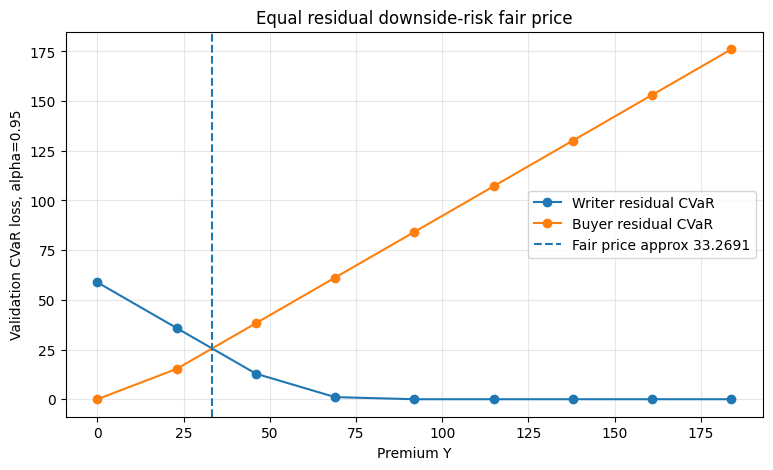

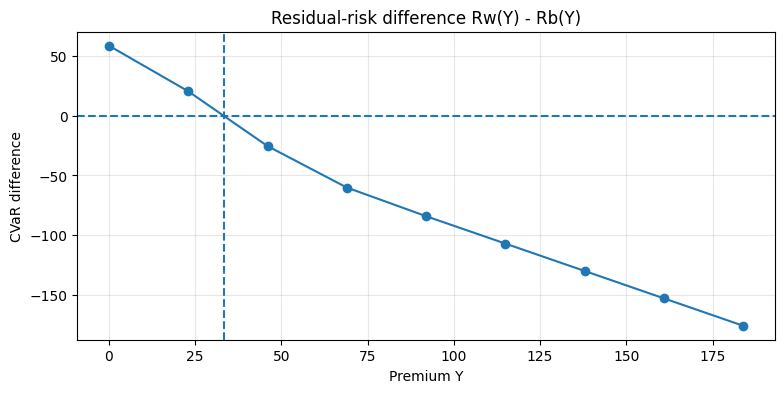

In [10]:
def make_default_price_grid(payoff_disc: np.ndarray, n_grid: int = 9) -> np.ndarray:
    """Create a reasonable initial premium grid from the scenario payoff scale."""
    payoff_disc = np.asarray(payoff_disc, dtype=float)
    mean_payoff = float(np.mean(payoff_disc))
    max_payoff = float(np.max(payoff_disc))
    p99 = float(np.quantile(payoff_disc, 0.99))

    upper = max(1.0, 3.0 * mean_payoff, 1.25 * p99, 0.75 * max_payoff)
    if upper <= 0.0 or not np.isfinite(upper):
        upper = 1.0
    return np.linspace(0.0, upper, n_grid, dtype=float)


def run_fair_price_grid(
    price_grid: np.ndarray,
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
    a_max: float,
    config: OptimConfig,
) -> Tuple[pd.DataFrame, Dict[Tuple[float, str], Dict[str, Any]]]:
    """Train writer and buyer strategies on a premium grid."""
    rows = []
    models = {}

    for j, Y in enumerate(price_grid):
        Y = float(Y)
        print(f"[{j + 1}/{len(price_grid)}] Premium Y = {Y:.6f}")

        # Writer receives premium, pays the claim.
        writer = train_best_strategy(
            train_data=train_data,
            val_data=val_data,
            x=Y,
            epsilon=-1,
            a_max=a_max,
            config=config,
        )

        # Buyer pays premium, receives the claim.
        buyer = train_best_strategy(
            train_data=train_data,
            val_data=val_data,
            x=-Y,
            epsilon=+1,
            a_max=a_max,
            config=config,
        )

        Rw = writer["validation"]["cvar_loss"]
        Rb = buyer["validation"]["cvar_loss"]
        diff = Rw - Rb

        rows.append({
            "Y": Y,
            "Rw_val_CVaR": Rw,
            "Rb_val_CVaR": Rb,
            "diff_Rw_minus_Rb": diff,
            "writer_mean_pnl": writer["validation"]["mean_pnl"],
            "buyer_mean_pnl": buyer["validation"]["mean_pnl"],
            "writer_prob_loss": writer["validation"]["prob_loss"],
            "buyer_prob_loss": buyer["validation"]["prob_loss"],
            "writer_avg_abs_a": writer["validation"]["avg_abs_position"],
            "buyer_avg_abs_a": buyer["validation"]["avg_abs_position"],
        })

        models[(Y, "writer")] = writer
        models[(Y, "buyer")] = buyer

        print(f"    Rw={Rw:.6f}, Rb={Rb:.6f}, Rw-Rb={diff:.6f}")

    result = pd.DataFrame(rows).sort_values("Y").reset_index(drop=True)
    return result, models


def estimate_fair_price_from_grid(result: pd.DataFrame) -> Dict[str, float]:
    """Estimate fair price by finding a sign crossing of Rw-Rb or closest grid point."""
    y = result["Y"].to_numpy(dtype=float)
    d = result["diff_Rw_minus_Rb"].to_numpy(dtype=float)

    for i in range(len(y) - 1):
        if d[i] == 0.0:
            return {"fair_price": float(y[i]), "method": "exact_grid", "abs_diff": 0.0}
        if d[i] * d[i + 1] < 0.0:
            # Linear interpolation between adjacent grid points.
            y0, y1 = y[i], y[i + 1]
            d0, d1 = d[i], d[i + 1]
            fair = y0 - d0 * (y1 - y0) / (d1 - d0)
            return {"fair_price": float(fair), "method": "linear_interpolation", "abs_diff": 0.0}

    # No crossing: return the grid point with smallest absolute residual-risk gap.
    idx = int(np.argmin(np.abs(d)))
    return {"fair_price": float(y[idx]), "method": "closest_grid", "abs_diff": float(abs(d[idx]))}


price_grid = make_default_price_grid(payoff_disc, N_PRICE_GRID)
print("Candidate premium grid:")
print(price_grid)

# Run the pricing grid. This is the slowest part because it trains two dynamic hedges per premium.
result_grid, trained_models = run_fair_price_grid(
    price_grid=price_grid,
    train_data=train_data,
    val_data=val_data,
    a_max=A_MAX,
    config=optim_config,
)

fair_estimate = estimate_fair_price_from_grid(result_grid)
print()
print("Fair-price estimate:")
print(fair_estimate)
print(result_grid)

plt.figure(figsize=(9, 5))
plt.plot(result_grid["Y"], result_grid["Rw_val_CVaR"], marker="o", label="Writer residual CVaR")
plt.plot(result_grid["Y"], result_grid["Rb_val_CVaR"], marker="o", label="Buyer residual CVaR")
plt.axvline(fair_estimate["fair_price"], linestyle="--", label=f"Fair price approx {fair_estimate['fair_price']:.4f}")
plt.title("Equal residual downside-risk fair price")
plt.xlabel("Premium Y")
plt.ylabel(f"Validation CVaR loss, alpha={ALPHA}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(result_grid["Y"], result_grid["diff_Rw_minus_Rb"], marker="o")
plt.axhline(0.0, linestyle="--")
plt.axvline(fair_estimate["fair_price"], linestyle="--")
plt.title("Residual-risk difference Rw(Y) - Rb(Y)")
plt.xlabel("Premium Y")
plt.ylabel("CVaR difference")
plt.grid(True, alpha=0.3)
plt.show()



## Optional final hedges and bank-account diagnostics


     side          Y  mean_pnl    std_pnl  mean_loss   var_loss  cvar_loss  \
0  writer  33.269147  3.383212  12.307033   3.523714  17.887264  25.545591   
1   buyer  33.269147  4.137283  31.205324   8.755441  23.762070  25.545587   

   prob_loss  avg_abs_position  
0   0.316667          0.608401  
1   0.586667          0.194969  
Max reconstruction error: 0.00021362305


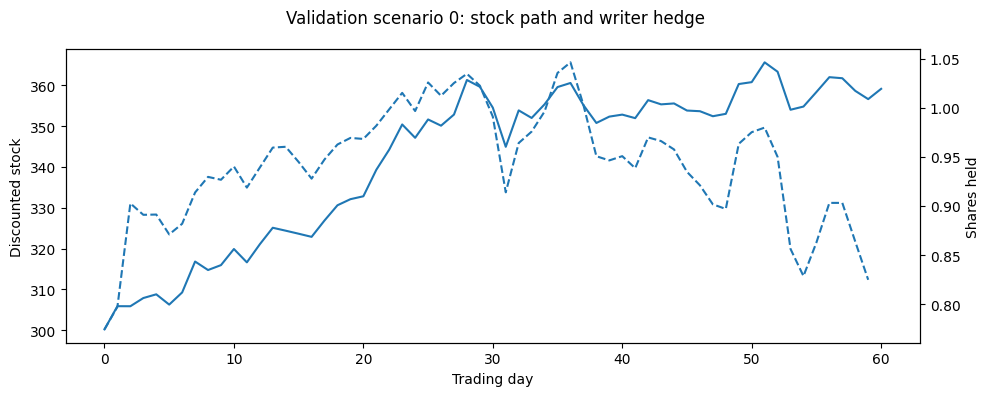

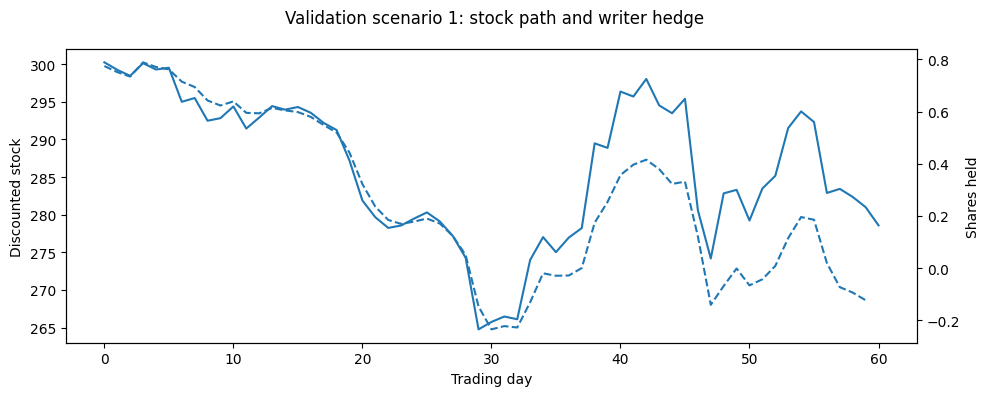

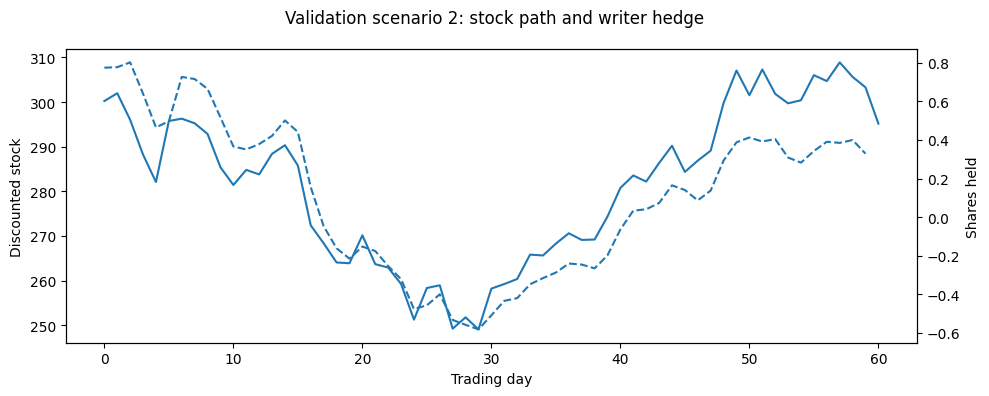

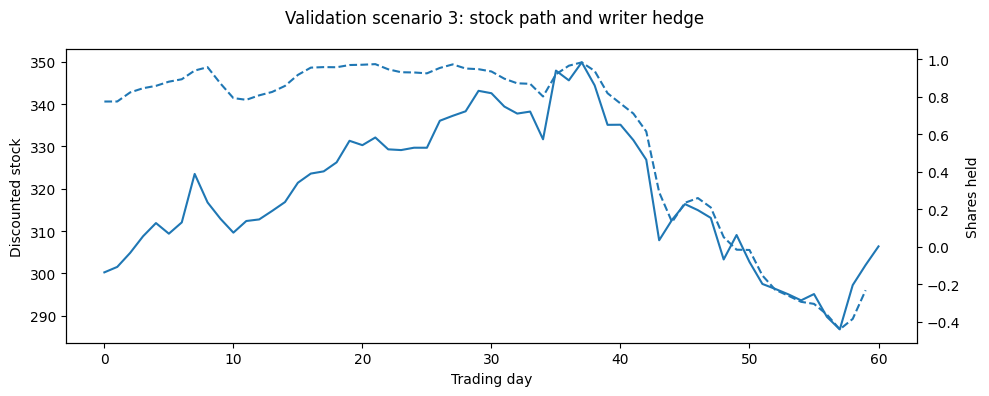

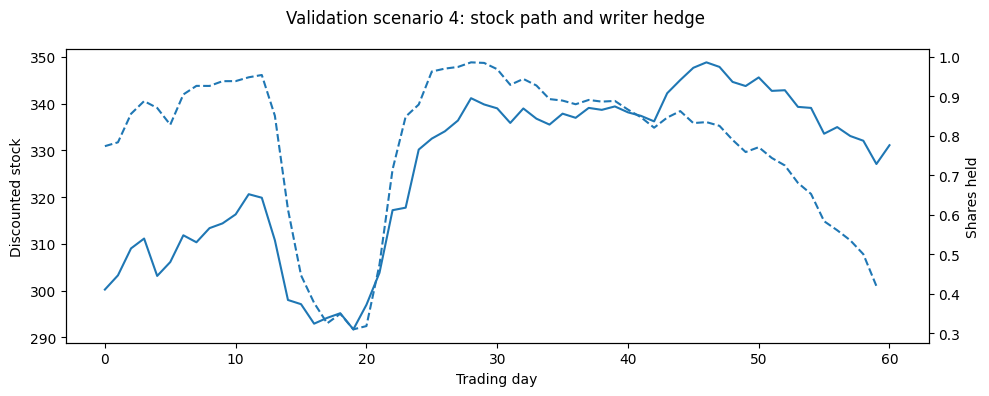

Validation scenario 0
  Discounted payoff: 67.0949
  Writer terminal wealth from hedge: 85.5979
  Writer terminal P&L after paying claim: 18.5030
  Writer downside loss: 0.0000

Validation scenario 1
  Discounted payoff: 0.0000
  Writer terminal wealth from hedge: 10.4813
  Writer terminal P&L after paying claim: 10.4813
  Writer downside loss: 0.0000

Validation scenario 2
  Discounted payoff: 10.6931
  Writer terminal wealth from hedge: 1.8998
  Writer terminal P&L after paying claim: -8.7933
  Writer downside loss: 8.7933

Validation scenario 3
  Discounted payoff: 50.8164
  Writer terminal wealth from hedge: 38.4965
  Writer terminal P&L after paying claim: -12.3199
  Writer downside loss: 12.3199

Validation scenario 4
  Discounted payoff: 50.1615
  Writer terminal wealth from hedge: 51.7796
  Writer terminal P&L after paying claim: 1.6182
  Writer downside loss: 0.0000



In [11]:
Y_FAIR = fair_estimate["fair_price"]

writer_fair = train_best_strategy(
    train_data=train_data,
    val_data=val_data,
    x=Y_FAIR,
    epsilon=-1,
    a_max=A_MAX,
    config=optim_config,
)

buyer_fair = train_best_strategy(
    train_data=train_data,
    val_data=val_data,
    x=-Y_FAIR,
    epsilon=+1,
    a_max=A_MAX,
    config=optim_config,
)

summary = pd.DataFrame([
    {"side": "writer", "Y": Y_FAIR, **writer_fair["validation"]},
    {"side": "buyer", "Y": Y_FAIR, **buyer_fair["validation"]},
])
print(summary)


def reconstruct_bank_account(
    model: nn.Module,
    data: Dict[str, np.ndarray],
    x: float,
) -> Dict[str, np.ndarray]:
    """
    Reconstruct discounted bank-account holdings from self-financing.

    b_0 = x - a_0 * S_0
    b_k = a_{k-1} * S_k + b_{k-1} - a_k * S_k
    W_k = a_k * S_k + b_k
    """
    model.eval()
    tdata = to_torch_data(data)
    with torch.no_grad():
        a = model(tdata["features"]).detach().cpu().numpy()

    S = data["S_disc"]
    M, N_plus_1 = S.shape
    N = N_plus_1 - 1
    b = np.zeros((M, N), dtype=np.float32)
    W = np.zeros((M, N), dtype=np.float32)

    b[:, 0] = float(x) - a[:, 0] * S[:, 0]
    W[:, 0] = a[:, 0] * S[:, 0] + b[:, 0]

    for k in range(1, N):
        b[:, k] = a[:, k - 1] * S[:, k] + b[:, k - 1] - a[:, k] * S[:, k]
        W[:, k] = a[:, k] * S[:, k] + b[:, k]

    terminal_wealth = a[:, -1] * S[:, -1] + b[:, -1]
    compact_wealth = float(x) + np.sum(a * (S[:, 1:] - S[:, :-1]), axis=1)
    max_error = np.max(np.abs(terminal_wealth - compact_wealth))

    return {"a": a, "b": b, "W": W, "terminal_wealth": terminal_wealth, "max_error": max_error}


writer_recon = reconstruct_bank_account(writer_fair["model"], val_data, x=Y_FAIR)
print("Max reconstruction error:", writer_recon["max_error"])

# Plot a few validation paths and the corresponding writer stock positions.
n_plot = min(5, len(val_data["S_disc"]))
for i in range(n_plot):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(val_data["S_disc"][i], label="Discounted stock path")
    ax1.set_xlabel("Trading day")
    ax1.set_ylabel("Discounted stock")
    ax2 = ax1.twinx()
    ax2.plot(np.arange(T_DAYS), writer_recon["a"][i], linestyle="--", label="Writer stock position a_k")
    ax2.set_ylabel("Shares held")
    fig.suptitle(f"Validation scenario {i}: stock path and writer hedge")
    fig.tight_layout()
    plt.show()
# Compute writer terminal P&L per validation scenario at the estimated fair price.
writer_terminal_wealth = writer_recon["terminal_wealth"]
writer_payoff = val_data["payoff_disc"]
writer_pnl = writer_terminal_wealth - writer_payoff

for i in range(n_plot):
    print(f"Validation scenario {i}")
    print(f"  Discounted payoff: {writer_payoff[i]:.4f}")
    print(f"  Writer terminal wealth from hedge: {writer_terminal_wealth[i]:.4f}")
    print(f"  Writer terminal P&L after paying claim: {writer_pnl[i]:.4f}")
    print(f"  Writer downside loss: {max(-writer_pnl[i], 0.0):.4f}")
    print()